In [1]:
from astropy.table import Table, vstack
from astroquery.gaia import Gaia
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [ ]:
reportable = pd.read_csv('(#path to#)reportable.csv', index_col='Unnamed: 0')
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']
reportable['abs_g_mag'] = reportable['phot_g_mean_mag'] - 5*np.log10(1000/reportable['parallax']) + 5
reportable['frac'] = reportable['sigma']/reportable['period']

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
cold = reportable[reportable['bp-rp'] >= 0.6]

nonoscillators = cold[cold['abs_g_mag'] > (2*cold['bp-rp'] - 4)]

subgiants = nonoscillators[nonoscillators['abs_g_mag'] < (1.4*nonoscillators['bp-rp']+2.8)]
ms = nonoscillators[nonoscillators['abs_g_mag'] >= (1.4*nonoscillators['bp-rp']+2.8)]

In [6]:
dr3_ids_ms = ms['dr3_source_id'].to_list()
dr3_ids_sg = subgiants['dr3_source_id'].to_list()
query_sg = f"SELECT gsource.source_id AS dr3_source_id, gsource.mass_flame, gsource.mass_flame_lower, gsource.mass_flame_upper, gsource.age_flame, gsource.age_flame_lower, gsource.age_flame_upper, cart.source_id AS dr3_id_2, cart.vrplane_med, cart.vz_med, cart.vphi_med, cart.energy_med FROM gaiadr3.astrophysical_parameters AS gsource INNER JOIN gaiadr3.chemical_cartography AS cart ON cart.source_id=gsource.source_id WHERE gsource.source_id IN ({','.join(map(str, dr3_ids_sg))}) "
query_ms = f"SELECT gsource.source_id AS dr3_source_id, gsource.mass_flame, gsource.mass_flame_lower, gsource.mass_flame_upper, gsource.age_flame, gsource.age_flame_lower, gsource.age_flame_upper, cart.source_id AS dr3_id_2, cart.vrplane_med, cart.vz_med, cart.vphi_med, cart.energy_med FROM gaiadr3.astrophysical_parameters AS gsource INNER JOIN gaiadr3.chemical_cartography AS cart ON cart.source_id=gsource.source_id WHERE gsource.source_id IN ({','.join(map(str, dr3_ids_ms))}) "


In [7]:
job1 = Gaia.launch_job(query_sg)
job2 = Gaia.launch_job(query_ms)

result_table_sg = job1.get_results().to_pandas().drop_duplicates(subset='dr3_source_id').drop(axis=1, columns='dr3_id_2')
result_table_ms = job2.get_results().to_pandas().drop_duplicates(subset='dr3_source_id').drop(axis=1, columns='dr3_id_2')

In [8]:
merged_sg = pd.merge(nonoscillators, result_table_sg, on='dr3_source_id', how='inner')
merged_ms = pd.merge(nonoscillators, result_table_ms, on='dr3_source_id', how='inner')

hasmass_sg = merged_sg.dropna(axis='rows', subset='mass_flame', how='any')
hasmass_ms = merged_ms.dropna(axis='rows', subset='mass_flame', how='any')

In [9]:
hasmass_sg['tau_conv'] = 10**(1.16 - (1.49*np.log10(hasmass_sg['mass_flame'])) - (0.54 * (np.log10(hasmass_sg['mass_flame']))**2))
hasmass_sg['rossby'] = hasmass_sg['period']/hasmass_sg['tau_conv']

hasmass_ms['tau_conv'] = 10**(1.16 - (1.49*np.log10(hasmass_ms['mass_flame'])) - (0.54 * (np.log10(hasmass_ms['mass_flame']))**2))
hasmass_ms['rossby'] = hasmass_ms['period']/hasmass_ms['tau_conv']

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_68298/4074451150.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hasmass_sg['tau_conv'] = 10**(1.16 - (1.49*np.log10(hasmass_sg['mass_flame'])) - (0.54 * (np.log10(hasmass_sg['mass_flame']))**2))
/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_68298/4074451150.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hasmass_sg['rossby'] = hasmass_sg['period']/hasmass_sg['tau_conv']
/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel

In [26]:
solar_prot_min = 25.67
solar_prot_max = 33.60
solar_tauconv = 10**1.16
solar_rossby_mi = solar_prot_min/solar_tauconv
solar_rossby_ma = solar_prot_max/solar_tauconv

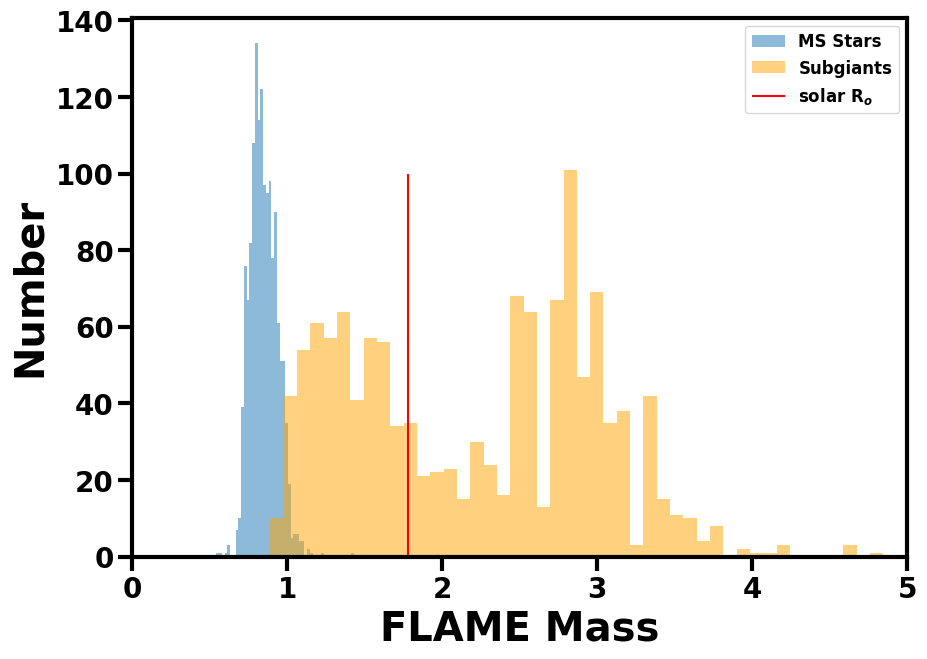

In [12]:
fig, ax = plt.subplots(1, figsize=(10, 7))
h = ax.hist(hasmass_ms['mass_flame'], bins=50, alpha=0.5, label='MS Stars')
h2 = ax.hist(hasmass_sg['mass_flame'], bins=50, color='orange', alpha=0.5, label="Subgiants")
ax.vlines(solar_rossby, ymin=0, ymax=100, color='r', label='solar R$_{o}$')
ax.set(xlabel='FLAME Mass', ylabel='Number', xlim=(0, 5))
ax.legend(fontsize=12)

# there appears to be a bimodality in the subgiants, lets cut them by mass

In [ ]:
lowmass = hasmass_sg[hasmass_sg['mass_flame'] < 2.1] #579 total
bigmass = hasmass_sg[hasmass_sg['mass_flame'] >= 2.1] #690 total
hasmass_ms #1470 total

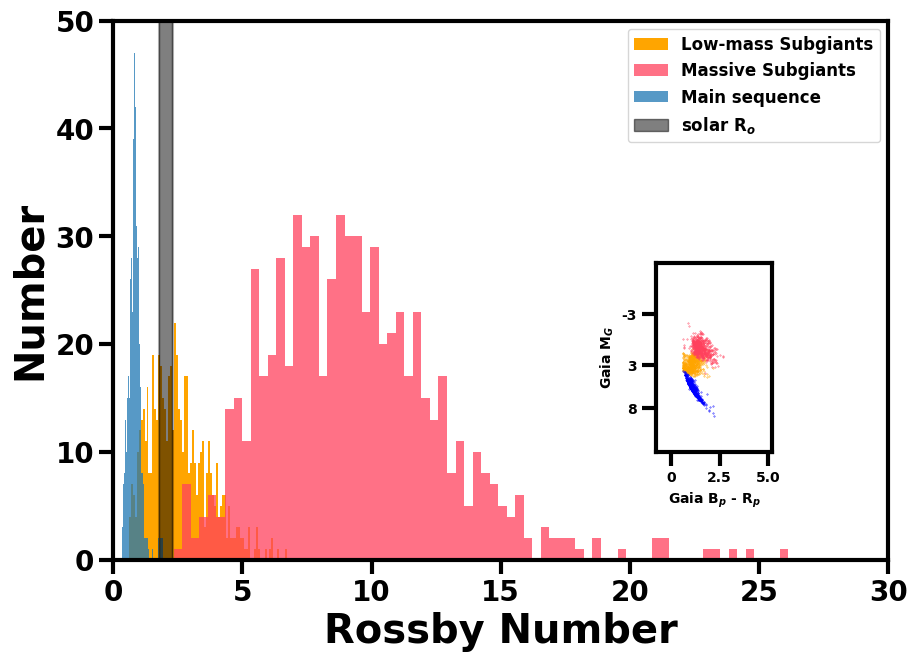

In [100]:
fig, ax = plt.subplots(1, figsize=(10, 7))

h2 = ax.hist(lowmass['rossby'], bins=80, color='orange', label="Low-mass Subgiants")
h3 = ax.hist(bigmass['rossby'], bins=120, color="#FF415D", label="Massive Subgiants", alpha=0.75)
h = ax.hist(hasmass_ms['rossby'], bins=180, label='Main sequence', alpha=0.75)
solar_ro_min = ax.vlines(solar_rossby_mi, ymin=0, ymax=50, color='black', alpha=0.25)
solar_ro_max = ax.vlines(solar_rossby_ma, ymin=0, ymax=50, color='black', alpha=0.25)
x=np.arange(solar_rossby_mi, solar_rossby_ma, 0.1)
ax.fill_between(x, 0, 50, alpha=0.5, color='k', label='solar R$_{o}$')

ax.set(xlabel='Rossby Number', ylabel='Number', xlim=(0, 30), ylim=(0, 50))
ax.legend(fontsize=12)

axin1 = ax.inset_axes([0.7, 0.2, 0.15, 0.35])

axin1.set(xlim=(-0.8, 5.2), ylim=(13.2, -9), xlabel='Gaia B$_p$ - R$_p$', ylabel='Gaia M$_G$')
im1 = axin1.scatter('bp-rp', 'abs_g_mag', data=lowmass, s=0.1, c ='orange', label='Low-mass Subgiants')
im1 = axin1.scatter('bp-rp', 'abs_g_mag', data=bigmass,  s=0.1, c="#FF415D", label='Massive Subgiants')
im1 = axin1.scatter('bp-rp', 'abs_g_mag', data=hasmass_ms, s=0.1, c='blue', label='Main sequence')
axin1.set_xlabel('Gaia B$_p$ - R$_p$', fontsize=10)
axin1.set_ylabel(f'Gaia M$_G$', fontsize=10)

axin1.set_xticks(ticks = [0, 2.5, 5.0], labels=[0, 2.5, 5.0], fontsize=10)
axin1.set_yticks(ticks = [-3, 3, 8], labels=[-3, 3, 8], fontsize=10)